In [12]:
!pip install open_clip_torch huggingface_hub semopy -q

In [16]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import open_clip
from huggingface_hub import hf_hub_download
import kagglehub

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler

In [39]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

INPUT = Path("/kaggle/input")
TILES_PATH = INPUT / "datasets/edwardsx/geovision-tiles-sit2"
if not TILES_PATH.exists():
    TILES_PATH = INPUT / "geovision-tiles-sit2"

MODEL_PATH = INPUT / "datasets/edwardsx/geovision-clip-modelo-v2"
if not MODEL_PATH.exists():
    MODEL_PATH = INPUT / "geovision-clip-modelo-v2"

OUTPUT = Path("/kaggle/working")
print(f"Tiles: {TILES_PATH}")
print(f"Modelo: {MODEL_PATH}")

TILE_PX = 64
TILE_PX_CLIP = 224
N_BANDAS_INPUT = 12
IDX_OPTICAS = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
BANDAS_OPTICAS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]

CLASES = [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "vegetacion_densa",
    "suelo_urbano",
]

SAE_HIDDEN = 256
SAE_LAMBDA = 1e-2
SAE_LR = 1e-3
SAE_EPOCHS = 100

Device: cuda
Tiles: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
Modelo: /kaggle/input/datasets/edwardsx/geovision-clip-modelo-v2


In [18]:
npz = np.load(TILES_PATH / "tiles_train.npz", allow_pickle=False)
tiles_arr = npz["data"]
bands = list(npz["bands"])
meta = pd.read_parquet(TILES_PATH / "tiles_meta.parquet")
print(f"Tiles: {tiles_arr.shape}")
print(f"Meta: {meta.shape}")

Tiles: (5000, 13, 64, 64)
Meta: (5000, 22)


In [19]:
ckpt_path = MODEL_PATH / "clip_finetuned_best.pt"
if not ckpt_path.exists():
    ckpt_path = Path(kagglehub.dataset_download("edwardsx/geovision-clip-modelo-v2")) / "clip_finetuned_best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
print(f"Checkpoint: epoch={ckpt.get('epoch', '?')}")

Checkpoint: epoch=11


In [22]:
clip_model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained=None)

# Adaptar conv1: 3ch -> 12ch
N_BANDAS_INPUT = 12
BANDAS_OPTICAS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]
orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(N_BANDAS_INPUT, orig_conv.out_channels, orig_conv.kernel_size,
                      stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = BANDAS_OPTICAS.index("B4")
    idx_g = BANDAS_OPTICAS.index("B3")
    idx_b = BANDAS_OPTICAS.index("B2")
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(N_BANDAS_INPUT):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / N_BANDAS_INPUT)
clip_model.visual.conv1 = new_conv
print("conv1 adaptada: 3ch -> 12ch")


conv1 adaptada: 3ch -> 12ch


In [31]:
clip_model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained=None)

# Adaptar conv1: 3ch -> 12ch
orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size,
                      stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx = {b: i for i, b in enumerate(["B4", "B3", "B2"])}
    w = new_conv.weight.data
    w[:, 0] = orig_conv.weight[:, idx["B4"]]
    w[:, 1] = orig_conv.weight[:, idx["B3"]]
    w[:, 2] = orig_conv.weight[:, idx["B2"]]
    mean = orig_conv.weight.mean(dim=1, keepdim=False) * (3.0 / 12)
    for b in range(3, 12):
        w[:, b] = mean
clip_model.visual.conv1 = new_conv

# Aplicar LoRA a bloques 6-11
class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16):
        super().__init__()
        self.linear = linear
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))
    @property
    def weight(self): return self.linear.weight
    @property
    def bias(self): return self.linear.bias
    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)

def aplicar_lora(module, rank=16):
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in {"out_proj", "c_fc", "c_proj"}:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank)

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=16)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=16)

# Cargar pesos
load_result = clip_model.load_state_dict(ckpt["clip"], strict=False)
print(f"Modelo: {len(load_result.missing_keys)} missing, {len(load_result.unexpected_keys)} unexpected")
clip_model = clip_model.to(DEVICE).eval()
print(f"Modelo en {DEVICE}")


Modelo: 0 missing, 0 unexpected
Modelo en cuda


In [32]:
class VisualProj(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(512, 512)
    def forward(self, x):
        return self.proj(x)

fusion = VisualProj()
fusion.load_state_dict(ckpt["fusion"])
fusion = fusion.to(DEVICE).eval()
print("Fusion cargada")

Fusion cargada


In [33]:
emb, y = generar_embeddings(tiles_arr, meta)
print(f"Embeddings: {emb.shape}")
print(f"Clases: {pd.Series(y).value_counts().to_string()}")

Embeddings:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings: torch.Size([5000, 512])
Clases: contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
vegetacion_densa          1000
suelo_urbano              1000


In [40]:
class SAE(nn.Module):
    def __init__(self, d_in=512, d_hidden=256):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_hidden)
        self.decoder = nn.Linear(d_hidden, d_in)

    def forward(self, x):
        z = torch.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z

sae = SAE(512, SAE_HIDDEN).to(DEVICE)
optim = torch.optim.Adam(sae.parameters(), lr=SAE_LR)
emb_t = emb.clone().to(DEVICE)
print(f"SAE: 512 -> {SAE_HIDDEN} -> 512")
print(f"Lambda L1: {SAE_LAMBDA}")

SAE: 512 -> 256 -> 512
Lambda L1: 0.01


In [41]:
history_sae = []
for epoch in range(1, SAE_EPOCHS + 1):
    x_hat, z = sae(emb_t)
    mse = F.mse_loss(x_hat, emb_t)
    l1 = z.abs().mean()
    loss = mse + SAE_LAMBDA * l1
    optim.zero_grad()
    loss.backward()
    optim.step()

    sparsity = (z.abs() < 0.01).float().mean().item()
    history_sae.append((epoch, mse.item(), l1.item(), sparsity))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | MSE={mse.item():.6f} | L1={l1.item():.6f} | sparsity={sparsity:.3f}")

print()
print(f"Final - MSE={history_sae[-1][1]:.6f}, sparsity={history_sae[-1][3]:.3f}")

Epoch   1 | MSE=0.003572 | L1=0.015695 | sparsity=0.587
Epoch  20 | MSE=0.000568 | L1=0.020002 | sparsity=0.681
Epoch  40 | MSE=0.000360 | L1=0.016346 | sparsity=0.706
Epoch  60 | MSE=0.000286 | L1=0.014353 | sparsity=0.725
Epoch  80 | MSE=0.000243 | L1=0.012898 | sparsity=0.744
Epoch 100 | MSE=0.000215 | L1=0.011643 | sparsity=0.764

Final - MSE=0.000215, sparsity=0.764


In [42]:
with torch.no_grad():
    _, z_all = sae(emb.clone().to(DEVICE))
z_all = z_all.cpu().numpy()

print(f"Hidden activations: {z_all.shape}")
print(f"Sparsity ratio (|z|<0.01): {(np.abs(z_all) < 0.01).mean():.3f}")
print(f"Neuronas activas promedio por muestra: {(z_all > 0.01).mean(axis=0).sum():.1f}")

Hidden activations: (5000, 256)
Sparsity ratio (|z|<0.01): 0.765
Neuronas activas promedio por muestra: 60.0


In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

emb_np = emb.numpy()
pca = PCA().fit(emb_np)

var_acum = np.cumsum(pca.explained_variance_ratio_)
n_80 = int(np.where(var_acum >= 0.80)[0][0]) + 1
n_90 = int(np.where(var_acum >= 0.90)[0][0]) + 1

print(f"Factores para 80% varianza: {n_80}")
print(f"Factores para 90% varianza: {n_90}")
print(f"Varianza explicada primeros 10 factores:")
for i in range(10):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} (acum: {var_acum[i]:.4f})")

Factores para 80% varianza: 6
Factores para 90% varianza: 21
Varianza explicada primeros 10 factores:
  PC1: 0.3161 (acum: 0.3161)
  PC2: 0.2226 (acum: 0.5387)
  PC3: 0.1303 (acum: 0.6691)
  PC4: 0.0857 (acum: 0.7548)
  PC5: 0.0320 (acum: 0.7867)
  PC6: 0.0197 (acum: 0.8065)
  PC7: 0.0145 (acum: 0.8209)
  PC8: 0.0117 (acum: 0.8326)
  PC9: 0.0093 (acum: 0.8419)
  PC10: 0.0086 (acum: 0.8505)


In [44]:
from sklearn.decomposition import FactorAnalysis

n_factores = max(n_80, 6)
fa = FactorAnalysis(n_components=n_factores, rotation="varimax", random_state=SEED)
cargas = fa.fit_transform(emb_np)

print(f"FactorAnalysis: {n_factores} factores con rotacion Varimax")
print(f"Cargas shape: {cargas.shape}")
print()

print("Media de carga absoluta por factor:")
for i in range(n_factores):
    print(f"  Factor {i+1}: media carga = {np.abs(fa.components_[i]).mean():.4f}")

FactorAnalysis: 6 factores con rotacion Varimax
Cargas shape: (5000, 6)

Media de carga absoluta por factor:
  Factor 1: media carga = 0.0180
  Factor 2: media carga = 0.0165
  Factor 3: media carga = 0.0112
  Factor 4: media carga = 0.0101
  Factor 5: media carga = 0.0057
  Factor 6: media carga = 0.0048


In [45]:
print("Varianza explicada por clase (primeros 2 componentes):")
for clase in CLASES:
    mask = y == clase
    print(f"  {clase[:30]:30s} PC1={pca.transform(emb_np)[mask, 0].mean():.3f} PC2={pca.transform(emb_np)[mask, 1].mean():.3f}")

Varianza explicada por clase (primeros 2 componentes):
  contaminacion_alta_NO2         PC1=0.258 PC2=0.165
  contaminacion_alta_SO2         PC1=-0.177 PC2=0.112
  ozono_anomalo                  PC1=-0.152 PC2=0.173
  vegetacion_densa               PC1=-0.564 PC2=-0.173
  suelo_urbano                   PC1=0.635 PC2=-0.277


In [59]:
from semopy import Model, calc_stats

# AFC con variables observables reales (metodologicamente correcto)
cols_afe = ["ndvi", "ndbi", "scl_pct", "era5_BLH",
            "era5_RH850", "era5_T2m", "era5_v10",
            "modis_WV", "era5_precip"]
df_sem = meta[cols_afe].copy()
for c in df_sem.columns:
    df_sem[c] = df_sem[c].fillna(df_sem[c].median())
df_sem = (df_sem - df_sem.mean()) / df_sem.std()

model_spec = """
CargaAntrop =~ era5_BLH + era5_T2m
EstresVeg =~ ndvi + era5_RH850 + era5_v10
DensUrbana =~ ndbi + scl_pct + era5_precip
Volatilidad =~ modis_WV + era5_RH850

ndvi ~~ ndbi
era5_T2m ~~ era5_BLH
era5_RH850 ~~ modis_WV
"""

mod = Model(model_spec)
mod.fit(df_sem)
stats = calc_stats(mod)
print("=== AFC (variables observables) ===")
print(stats)
print()

CFI = stats.loc["Value", "CFI"] if "CFI" in stats.columns else None
RMSEA = stats.loc["Value", "RMSEA"] if "RMSEA" in stats.columns else None
print(f"CFI   = {CFI:.3f}  (meta: > 0.90)")
print(f"RMSEA = {RMSEA:.3f}  (meta: < 0.08)")
print()


=== AFC (variables observables) ===
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value   17            36  1025.253894           0.0   15111.334265  0.933119   

            GFI      AGFI       NFI      TLI     RMSEA        AIC         BIC  \
Value  0.932153  0.856325  0.932153  0.85837  0.108923  55.589898  238.071308   

         LogLik  
Value  0.205051  

CFI   = 0.933  (meta: > 0.90)
RMSEA = 0.109  (meta: < 0.08)



In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = OUTPUT / "figuras_sae"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAE curves: /kaggle/working/figuras_sae/sae_curvas.png


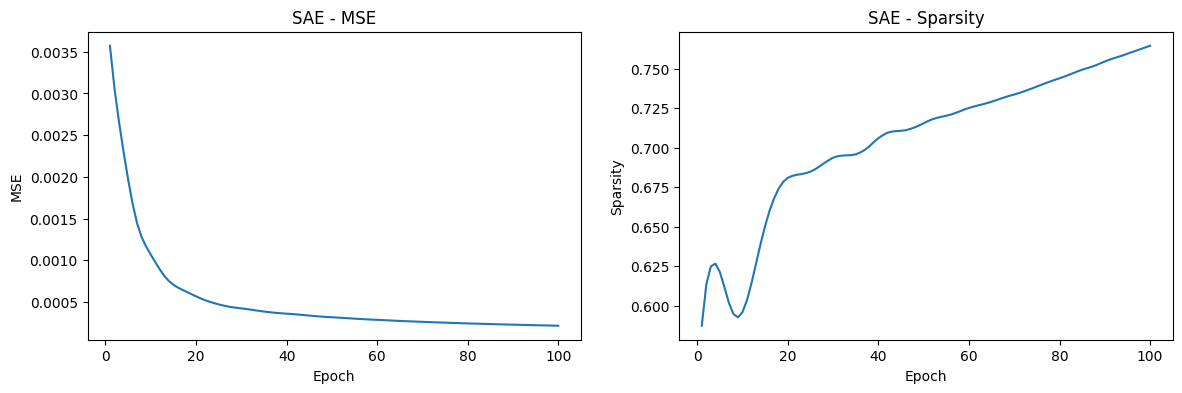

In [64]:
hist = np.array(history_sae)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist[:, 0], hist[:, 1])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].set_title("SAE - MSE")
axes[1].plot(hist[:, 0], hist[:, 3])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Sparsity"); axes[1].set_title("SAE - Sparsity")
fig.savefig(str(FIG_DIR / "sae_curvas.png"), dpi=130, bbox_inches="tight")
print(f"SAE curves: {FIG_DIR / 'sae_curvas.png'}")

PCA scatter: /kaggle/working/figuras_sae/pca_embeddings.png


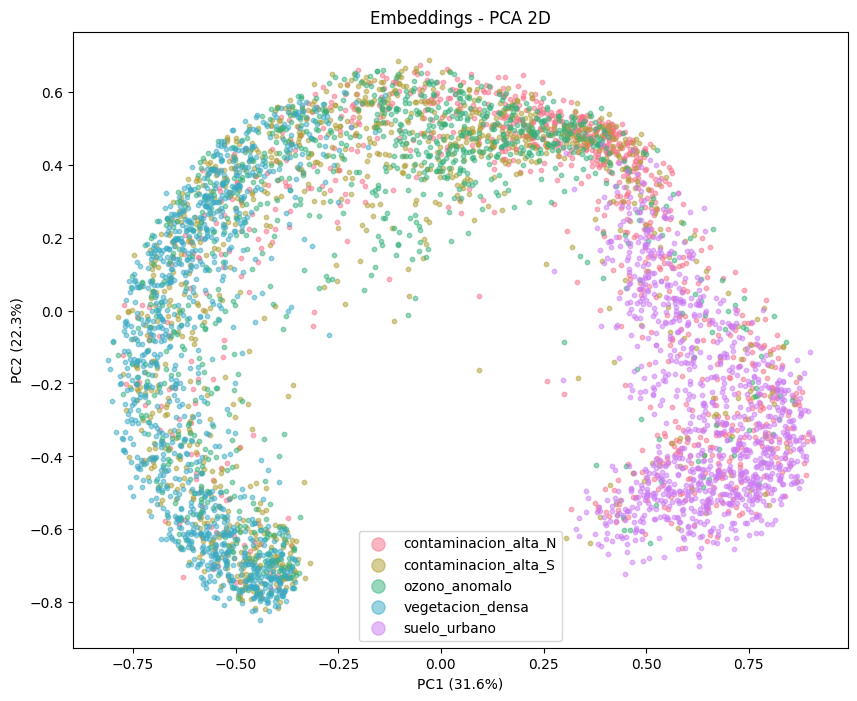

In [67]:
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(emb_np)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette("husl", len(CLASES))
for i, clase in enumerate(CLASES):
    mask = y == clase
    ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], c=[palette[i]],
               label=clase[:20], alpha=0.5, s=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Embeddings - PCA 2D")
ax.legend(markerscale=3)
fig.savefig(str(FIG_DIR / "pca_embeddings.png"), dpi=130, bbox_inches="tight")
print(f"PCA scatter: {FIG_DIR / 'pca_embeddings.png'}")

SAE activations: /kaggle/working/figuras_sae/sae_activaciones.png

--- Resumen numerico de activaciones SAE por clase ---
contaminacion_alta_NO2         | media=0.0116 | mediana=0.0000 | p90=0.0440 | max=0.2926 | %cero=69.9%
contaminacion_alta_SO2         | media=0.0115 | mediana=0.0000 | p90=0.0435 | max=0.2793 | %cero=69.5%
ozono_anomalo                  | media=0.0116 | mediana=0.0000 | p90=0.0435 | max=0.2987 | %cero=69.3%
vegetacion_densa               | media=0.0117 | mediana=0.0000 | p90=0.0445 | max=0.2938 | %cero=69.5%
suelo_urbano                   | media=0.0117 | mediana=0.0000 | p90=0.0436 | max=0.3127 | %cero=69.4%


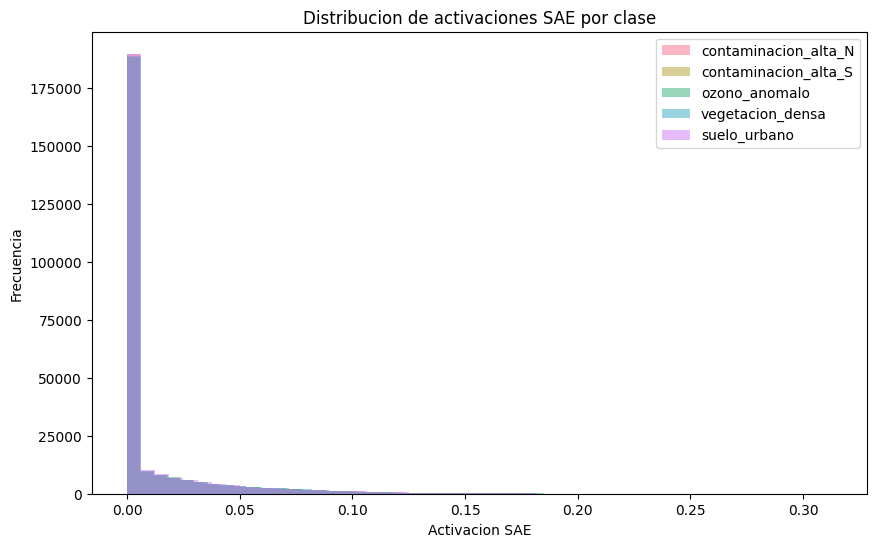

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, clase in enumerate(CLASES):
    mask = y == clase
    ax.hist(z_all[mask, :].ravel(), bins=50, alpha=0.5, label=clase[:20],
            color=palette[i], histtype="stepfilled", linewidth=1)
ax.set_xlabel("Activacion SAE"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion de activaciones SAE por clase")
ax.legend()
fig.savefig(str(FIG_DIR / "sae_activaciones.png"), dpi=130, bbox_inches="tight")
print(f"SAE activations: {FIG_DIR / 'sae_activaciones.png'}")
print()
print("--- Resumen numerico de activaciones SAE por clase ---")
for i, clase in enumerate(CLASES):
    vals = z_all[y == clase].ravel()
    print(f"{clase[:30]:30s} | media={vals.mean():.4f} | mediana={np.median(vals):.4f} | "
          f"p90={np.percentile(vals, 90):.4f} | max={vals.max():.4f} | "
          f"%cero={(vals==0).mean()*100:.1f}%")


=== Top-10 neuronas SAE mas activas por clase ===

contaminacion_alta_NO2         | neuronas: [108 241   2  37 207] | activacion: [0.0913 0.0553 0.053  0.0521 0.0513]
contaminacion_alta_SO2         | neuronas: [108 126  49 207 222] | activacion: [0.0844 0.0698 0.0669 0.0565 0.0434]
ozono_anomalo                  | neuronas: [108  49  34 126 207] | activacion: [0.0982 0.0766 0.0644 0.0638 0.0581]
vegetacion_densa               | neuronas: [141  78 123 222  10] | activacion: [0.0713 0.0686 0.0675 0.0634 0.0624]
suelo_urbano                   | neuronas: [209  72 171 215  14] | activacion: [0.0858 0.0698 0.0664 0.0664 0.0655]

Heatmap: /kaggle/working/figuras_sae/sae_top_neurons.png


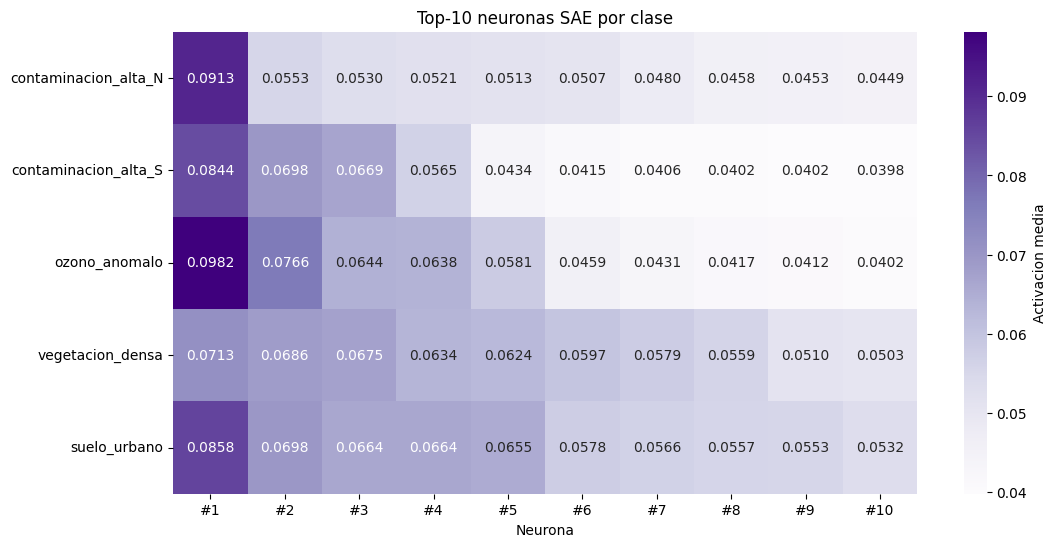

In [71]:
print("=== Top-10 neuronas SAE mas activas por clase ===\n")
top_n = 10
top_neurons = {}
for clase in CLASES:
    mask = y == clase
    activ_media = z_all[mask].mean(axis=0)
    top_idx = np.argsort(activ_media)[-top_n:][::-1]
    top_neurons[clase] = (top_idx, activ_media[top_idx])
    print(f"{clase[:30]:30s} | neuronas: {str(top_idx[:5]):20s} | activacion: {np.array2string(activ_media[top_idx][:5], precision=4)}")

fig, ax = plt.subplots(figsize=(12, 6))
data_heat = np.array([top_neurons[c][1] for c in CLASES])
sns.heatmap(data_heat, xticklabels=[f"#{i}" for i in range(1, top_n + 1)],
            yticklabels=[c[:20] for c in CLASES], annot=True, fmt=".4f",
            cmap="Purples", ax=ax, cbar_kws={"label": "Activacion media"})
ax.set_title("Top-10 neuronas SAE por clase"); ax.set_xlabel("Neurona")
fig.savefig(str(FIG_DIR / "sae_top_neurons.png"), dpi=130, bbox_inches="tight")
print(f"\nHeatmap: {FIG_DIR / 'sae_top_neurons.png'}")